# EM Algorithm Demo: Netflix Movie Ratings

This notebook demonstrates the Expectation-Maximization (EM) algorithm using a Netflix-style example where we have movie ratings from two different user groups (sci-fi lovers vs romance lovers).

## Problem Setup
- **Group 1**: Sci-fi lovers (rate action/sci-fi movies highly)
- **Group 2**: Romance lovers (rate romance movies highly)
- **Challenge**: We don't know which group each user belongs to!
- **Goal**: Learn the group characteristics and classify users


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Generate Synthetic Data

Let's create our "Netflix" dataset with two user groups:


In [7]:
# True parameters (we'll pretend we don't know these)
true_params = {
    'pi1': 0.6,  # 60% sci-fi lovers
    'pi2': 0.4,  # 40% romance lovers
    'mu1': 7.5,  # Sci-fi lovers rate highly
    'mu2': 4.0,  # Romance lovers rate moderately
    'sigma1': 1.2,  # Sci-fi lovers have moderate variance
    'sigma2': 1.5   # Romance lovers have higher variance
}

print("True parameters:")
for key, value in true_params.items():
    print(f"  {key}: {value}")


True parameters:
  pi1: 0.6
  pi2: 0.4
  mu1: 7.5
  mu2: 4.0
  sigma1: 1.2
  sigma2: 1.5


In [8]:
# Generate synthetic data
n_users = 200

# Assign users to groups (we'll pretend we don't know this)
true_groups = np.random.choice([0, 1], size=n_users, p=[true_params['pi1'], true_params['pi2']])

# Generate ratings based on group membership
ratings = np.zeros(n_users)
for i in range(n_users):
    if true_groups[i] == 0:  # Sci-fi lover
        ratings[i] = np.random.normal(true_params['mu1'], true_params['sigma1'])
    else:  # Romance lover
        ratings[i] = np.random.normal(true_params['mu2'], true_params['sigma2'])

# Clip ratings to [1, 10] range (realistic movie ratings)
ratings = np.clip(ratings, 1, 10)

print(f"Generated {n_users} user ratings")
print(f"Rating range: {ratings.min():.1f} to {ratings.max():.1f}")
print(f"Average rating: {ratings.mean():.2f}")


Generated 200 user ratings
Rating range: 1.2 to 10.0
Average rating: 6.21


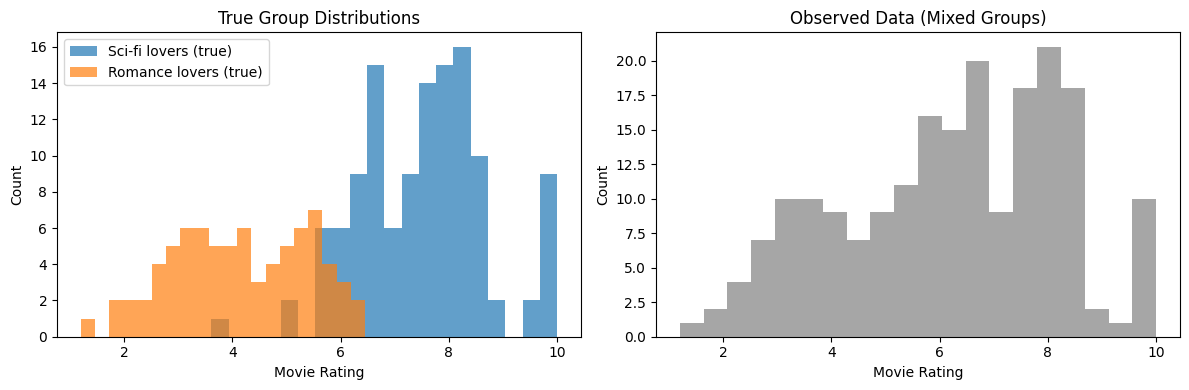


Note: In reality, we only see the mixed data on the right!


In [9]:
# Visualize the data
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(ratings[true_groups == 0], alpha=0.7, label='Sci-fi lovers (true)', bins=20)
plt.hist(ratings[true_groups == 1], alpha=0.7, label='Romance lovers (true)', bins=20)
plt.xlabel('Movie Rating')
plt.ylabel('Count')
plt.title('True Group Distributions')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(ratings, alpha=0.7, bins=20, color='gray')
plt.xlabel('Movie Rating')
plt.ylabel('Count')
plt.title('Observed Data (Mixed Groups)')

plt.tight_layout()
plt.show()

print("\nNote: In reality, we only see the mixed data on the right!")


## 2. EM Algorithm Implementation

Now let's implement the EM algorithm to recover the group structure from the mixed data.


In [11]:
class EMAnalyzer:
    def __init__(self, data):
        self.data = data
        self.n = len(data)
        
    def initialize_parameters(self):
        """Initialize parameters randomly"""
        self.params = {
            'pi1': 0.5,  # Start with equal mixing proportions
            'pi2': 0.5,
            'mu1': np.random.uniform(3, 8),  # Random mean for group 1
            'mu2': np.random.uniform(3, 8),  # Random mean for group 2
            'sigma1': np.random.uniform(0.5, 2),  # Random std for group 1
            'sigma2': np.random.uniform(0.5, 2)   # Random std for group 2
        }
        
    def normal_pdf(self, x, mu, sigma):
        """Normal probability density function"""
        return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    
    def e_step(self):
        """Expectation step: Compute posterior probabilities"""
        print("\n=== E-STEP ===")
        
        # Compute likelihoods for each group
        likelihood1 = self.normal_pdf(self.data, self.params['mu1'], self.params['sigma1'])
        likelihood2 = self.normal_pdf(self.data, self.params['mu2'], self.params['sigma2'])
        
        # Compute posterior probabilities (gamma_ik)
        numerator1 = self.params['pi1'] * likelihood1
        numerator2 = self.params['pi2'] * likelihood2
        denominator = numerator1 + numerator2
        
        self.gamma1 = numerator1 / denominator  # P(user i is in group 1)
        self.gamma2 = numerator2 / denominator  # P(user i is in group 2)
        
        print(f"Posterior probabilities computed for {self.n} users")
        print(f"Average P(group 1): {self.gamma1.mean():.3f}")
        print(f"Average P(group 2): {self.gamma2.mean():.3f}")
        
        return self.gamma1, self.gamma2
    
    def m_step(self):
        """Maximization step: Update parameters"""
        print("\n=== M-STEP ===")
        
        # Update mixing proportions
        old_pi1 = self.params['pi1']
        old_pi2 = self.params['pi2']
        
        self.params['pi1'] = self.gamma1.mean()
        self.params['pi2'] = self.gamma2.mean()
        
        print(f"Mixing proportions: π₁ = {self.params['pi1']:.3f} (was {old_pi1:.3f})")
        print(f"                 π₂ = {self.params['pi2']:.3f} (was {old_pi2:.3f})")
        
        # Update means
        old_mu1 = self.params['mu1']
        old_mu2 = self.params['mu2']
        
        self.params['mu1'] = np.sum(self.gamma1 * self.data) / np.sum(self.gamma1)
        self.params['mu2'] = np.sum(self.gamma2 * self.data) / np.sum(self.gamma2)
        
        print(f"Means: μ₁ = {self.params['mu1']:.3f} (was {old_mu1:.3f})")
        print(f"       μ₂ = {self.params['mu2']:.3f} (was {old_mu2:.3f})")
        
        # Update variances
        old_sigma1 = self.params['sigma1']
        old_sigma2 = self.params['sigma2']
        
        self.params['sigma1'] = np.sqrt(np.sum(self.gamma1 * (self.data - self.params['mu1'])**2) / np.sum(self.gamma1))
        self.params['sigma2'] = np.sqrt(np.sum(self.gamma2 * (self.data - self.params['mu2'])**2) / np.sum(self.gamma2))
        
        print(f"Std devs: σ₁ = {self.params['sigma1']:.3f} (was {old_sigma1:.3f})")
        print(f"          σ₂ = {self.params['sigma2']:.3f} (was {old_sigma2:.3f})")
        
        return self.params
    
    def compute_log_likelihood(self):
        """Compute log-likelihood of current parameters"""
        likelihood1 = self.normal_pdf(self.data, self.params['mu1'], self.params['sigma1'])
        likelihood2 = self.normal_pdf(self.data, self.params['mu2'], self.params['sigma2'])
        
        # Marginal likelihood (mixture)
        marginal_likelihood = self.params['pi1'] * likelihood1 + self.params['pi2'] * likelihood2
        
        # Log-likelihood
        log_likelihood = np.sum(np.log(marginal_likelihood + 1e-10))  # Add small value to avoid log(0)
        
        return log_likelihood
    
    def fit(self, max_iterations=20, tolerance=1e-4):
        """Run EM algorithm until convergence"""
        print("Starting EM Algorithm...")
        print("=" * 50)
        
        self.initialize_parameters()
        
        log_likelihoods = []
        
        for iteration in range(max_iterations):
            print(f"\n--- ITERATION {iteration + 1} ---")
            
            # E-step
            self.e_step()
            
            # M-step
            self.m_step()
            
            # Compute log-likelihood
            log_likelihood = self.compute_log_likelihood()
            log_likelihoods.append(log_likelihood)
            
            print(f"\nLog-likelihood: {log_likelihood:.2f}")
            
            # Check convergence
            if iteration > 0:
                improvement = log_likelihood - log_likelihoods[-2]
                print(f"Improvement: {improvement:.4f}")
                
                if abs(improvement) < tolerance:
                    print(f"\nConverged after {iteration + 1} iterations!")
                    break
        
        return log_likelihoods

print("EM Algorithm class defined!")


EM Algorithm class defined!


## 3. Run EM Algorithm

Let's run the algorithm and see how it learns the group structure:


In [12]:
# Create EM analyzer and run algorithm
em = EMAnalyzer(ratings)
log_likelihoods = em.fit(max_iterations=15, tolerance=1e-4)

print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)

print("\nEstimated Parameters:")
for key, value in em.params.items():
    print(f"  {key}: {value:.3f}")

print("\nTrue Parameters:")
for key, value in true_params.items():
    print(f"  {key}: {value:.3f}")


Starting EM Algorithm...

--- ITERATION 1 ---

=== E-STEP ===
Posterior probabilities computed for 200 users
Average P(group 1): 0.412
Average P(group 2): 0.588

=== M-STEP ===
Mixing proportions: π₁ = 0.412 (was 0.500)
                 π₂ = 0.588 (was 0.500)
Means: μ₁ = 4.536 (was 5.121)
       μ₂ = 7.386 (was 7.532)
Std devs: σ₁ = 1.220 (was 0.667)
          σ₂ = 1.616 (was 1.239)

Log-likelihood: -425.50

--- ITERATION 2 ---

=== E-STEP ===
Posterior probabilities computed for 200 users
Average P(group 1): 0.381
Average P(group 2): 0.619

=== M-STEP ===
Mixing proportions: π₁ = 0.381 (was 0.412)
                 π₂ = 0.619 (was 0.588)
Means: μ₁ = 4.340 (was 4.536)
       μ₂ = 7.366 (was 7.386)
Std devs: σ₁ = 1.424 (was 1.220)
          σ₂ = 1.384 (was 1.616)

Log-likelihood: -417.92
Improvement: 7.5786

--- ITERATION 3 ---

=== E-STEP ===
Posterior probabilities computed for 200 users
Average P(group 1): 0.375
Average P(group 2): 0.625

=== M-STEP ===
Mixing proportions: π₁ = 0.375 

## 4. Visualize Results

Let's see how well our learned model fits the data:


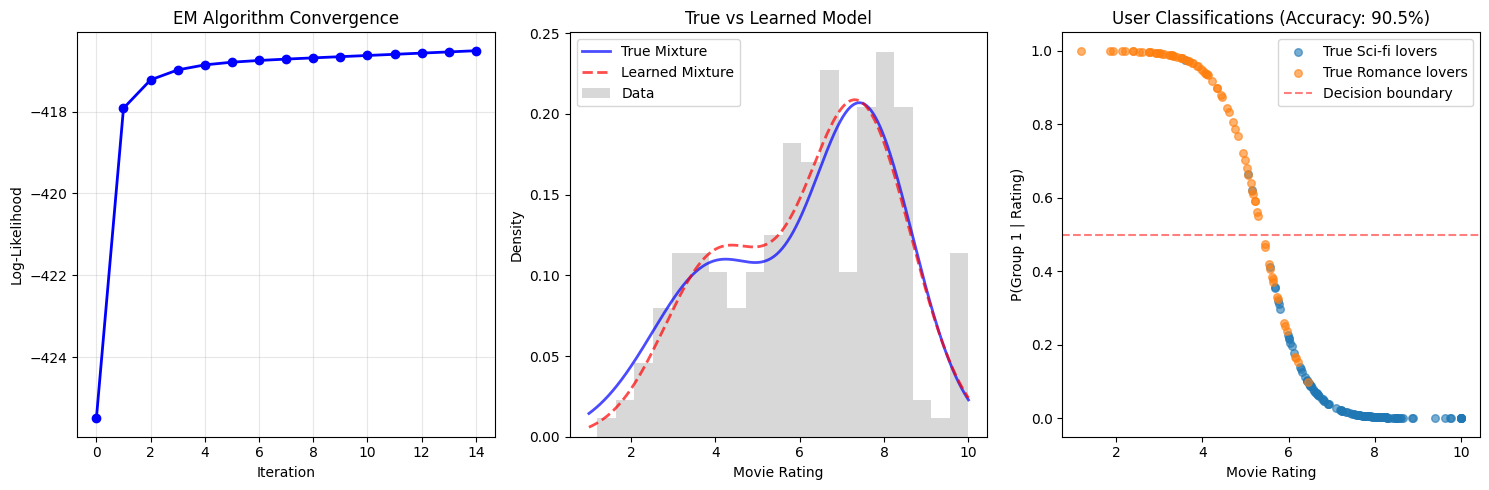

Classification Accuracy: 90.5%
Final log-likelihood: -416.51
Total improvement: 8.98


In [13]:
# Plot convergence
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(log_likelihoods, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('EM Algorithm Convergence')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
# Create visualization of learned model
x_range = np.linspace(1, 10, 1000)

# True distributions
true_dist1 = true_params['pi1'] * norm.pdf(x_range, true_params['mu1'], true_params['sigma1'])
true_dist2 = true_params['pi2'] * norm.pdf(x_range, true_params['mu2'], true_params['sigma2'])
true_mixture = true_dist1 + true_dist2

# Learned distributions
learned_dist1 = em.params['pi1'] * norm.pdf(x_range, em.params['mu1'], em.params['sigma1'])
learned_dist2 = em.params['pi2'] * norm.pdf(x_range, em.params['mu2'], em.params['sigma2'])
learned_mixture = learned_dist1 + learned_dist2

plt.plot(x_range, true_mixture, 'b-', linewidth=2, label='True Mixture', alpha=0.7)
plt.plot(x_range, learned_mixture, 'r--', linewidth=2, label='Learned Mixture', alpha=0.7)
plt.hist(ratings, bins=20, density=True, alpha=0.3, color='gray', label='Data')
plt.xlabel('Movie Rating')
plt.ylabel('Density')
plt.title('True vs Learned Model')
plt.legend()

plt.subplot(1, 3, 3)
# User Classifications
predicted_groups = (em.gamma1 > 0.5).astype(int)
accuracy = np.mean(predicted_groups == true_groups)

plt.scatter(ratings[true_groups == 0], em.gamma1[true_groups == 0], 
           alpha=0.6, label='True Sci-fi lovers', s=30)
plt.scatter(ratings[true_groups == 1], em.gamma1[true_groups == 1], 
           alpha=0.6, label='True Romance lovers', s=30)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Decision boundary')
plt.xlabel('Movie Rating')
plt.ylabel('P(Group 1 | Rating)')
plt.title(f'User Classifications (Accuracy: {accuracy:.1%})')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Classification Accuracy: {accuracy:.1%}")
print(f"Final log-likelihood: {log_likelihoods[-1]:.2f}")
print(f"Total improvement: {log_likelihoods[-1] - log_likelihoods[0]:.2f}")


## 5. How to Use EM Algorithm - Step by Step

Here's a simple guide on how to use the EM algorithm:


In [14]:
# STEP 1: Prepare your data
print("STEP 1: Prepare your data")
print("-" * 30)
print("• Your data should be a 1D array of observations")
print("• Example: movie ratings, test scores, measurements")
print(f"• Our data: {len(ratings)} movie ratings from {n_users} users")
print(f"• Data range: {ratings.min():.1f} to {ratings.max():.1f}")
print()

# STEP 2: Initialize the EM analyzer
print("STEP 2: Initialize the EM analyzer")
print("-" * 30)
print("• Create an EMAnalyzer object with your data")
print("• The analyzer will automatically initialize random parameters")
print("• You can adjust max_iterations and tolerance as needed")
print()

# STEP 3: Run the algorithm
print("STEP 3: Run the algorithm")
print("-" * 30)
print("• Call the fit() method to run EM")
print("• The algorithm will alternate between E-step and M-step")
print("• It stops when convergence is reached or max iterations hit")
print()

# STEP 4: Interpret results
print("STEP 4: Interpret results")
print("-" * 30)
print("• Check the learned parameters (means, variances, mixing proportions)")
print("• Use posterior probabilities (gamma) to classify observations")
print("• Visualize the learned model vs your data")
print()

# STEP 5: Use the learned model
print("STEP 5: Use the learned model")
print("-" * 30)
print("• Classify new observations using the learned parameters")
print("• Generate new data from the learned mixture model")
print("• Make predictions about group membership")


STEP 1: Prepare your data
------------------------------
• Your data should be a 1D array of observations
• Example: movie ratings, test scores, measurements
• Our data: 200 movie ratings from 200 users
• Data range: 1.2 to 10.0

STEP 2: Initialize the EM analyzer
------------------------------
• Create an EMAnalyzer object with your data
• The analyzer will automatically initialize random parameters
• You can adjust max_iterations and tolerance as needed

STEP 3: Run the algorithm
------------------------------
• Call the fit() method to run EM
• The algorithm will alternate between E-step and M-step
• It stops when convergence is reached or max iterations hit

STEP 4: Interpret results
------------------------------
• Check the learned parameters (means, variances, mixing proportions)
• Use posterior probabilities (gamma) to classify observations
• Visualize the learned model vs your data

STEP 5: Use the learned model
------------------------------
• Classify new observations using 

In [15]:
# Example: Classify a new user
print("EXAMPLE: Classify a new user")
print("=" * 40)

# Simulate a new user with rating 8.5
new_rating = 8.5
print(f"New user rating: {new_rating}")

# Compute posterior probabilities for this new user
likelihood1 = em.normal_pdf(new_rating, em.params['mu1'], em.params['sigma1'])
likelihood2 = em.normal_pdf(new_rating, em.params['mu2'], em.params['sigma2'])

numerator1 = em.params['pi1'] * likelihood1
numerator2 = em.params['pi2'] * likelihood2
denominator = numerator1 + numerator2

prob_group1 = numerator1 / denominator
prob_group2 = numerator2 / denominator

print(f"P(Sci-fi lover | rating={new_rating}): {prob_group1:.3f}")
print(f"P(Romance lover | rating={new_rating}): {prob_group2:.3f}")

if prob_group1 > prob_group2:
    print(f"→ This user is likely a SCI-FI LOVER! (confidence: {prob_group1:.1%})")
else:
    print(f"→ This user is likely a ROMANCE LOVER! (confidence: {prob_group2:.1%})")

print()
print("This is how you use EM to make predictions on new data!")


EXAMPLE: Classify a new user
New user rating: 8.5
P(Sci-fi lover | rating=8.5): 0.001
P(Romance lover | rating=8.5): 0.999
→ This user is likely a ROMANCE LOVER! (confidence: 99.9%)

This is how you use EM to make predictions on new data!


## 6. Summary: How to Use EM Algorithm

### Quick Start Guide:

```python
# 1. Import and prepare data
import numpy as np
from your_em_class import EMAnalyzer

data = np.array([your_observations])  # 1D array

# 2. Create and run EM
em = EMAnalyzer(data)
log_likelihoods = em.fit(max_iterations=20, tolerance=1e-4)

# 3. Get results
learned_params = em.params
posterior_probs = em.gamma1, em.gamma2

# 4. Classify new data
new_observation = 5.2
prob_group1 = compute_posterior(new_observation, em.params)
```

### Key Points:
- **Input**: 1D array of observations
- **Output**: Learned group parameters and classification probabilities
- **Convergence**: Algorithm stops when log-likelihood improvement is small
- **Classification**: Use posterior probabilities to assign observations to groups
- **Flexibility**: Works with any mixture of distributions (not just normal)
